In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [2]:
N_IND   = 100
L_IND   = 33
PC      = 0.9
PM      = 0.01
MAX_GEN = 1000
N_VAR   = 2
RANGO   = np.array([[-3.0, 4.1],
                    [12.1, 5.8]])
 
np.random.seed(42)

In [3]:
def crear_poblacion(n, l):
    """Genera una población inicial aleatoria de n individuos con cromosomas de longitud l."""
    return np.random.randint(0, 2, size=(n, l))
 
 
def decodificar(cromosomas, rango):
    """Convierte cromosomas binarios a valores reales dentro del rango dado."""
    n_var  = rango.shape[1]
    n, l   = cromosomas.shape
    l_var  = l // n_var
    pesos  = 2 ** np.arange(l_var)
    real   = np.zeros((n, n_var))
 
    for i in range(n):
        for j in range(n_var):
            segmento    = cromosomas[i, j*l_var : j*l_var + l_var]
            real[i, j]  = np.dot(pesos, segmento)
 
    for j in range(n_var):
        lo, hi     = rango[j, 0], rango[j, 1]
        real[:, j] = lo + (hi - lo) / (2**l_var - 1) * real[:, j]
 
    return real
 
 
def evaluar(fenotipos):
    """Evalúa f(x, y) = 21.5 + x·sen(4πx) + y·sen(20πy) para cada individuo."""
    n, _ = fenotipos.shape
    vals = np.zeros((n, 1))
    for i in range(n):
        x, y      = fenotipos[i, 0], fenotipos[i, 1]
        vals[i, 0] = 21.5 + x * np.sin(4*np.pi*x) + y * np.sin(20*np.pi*y)
    return vals
 
 
def calcular_aptitud(obj_vals, maximizar=True):
    """Asigna aptitud por rankeo lineal. Garantiza valores positivos para la ruleta."""
    SP    = 2
    n, _  = obj_vals.shape
    apt   = np.zeros((n, 1))
    orden = np.sort(obj_vals, axis=0) if maximizar else np.sort(-obj_vals, axis=0)
    vals  = 2 - SP + 2*(SP-1) * (np.arange(n) / (n-1))
    pos   = np.argsort(orden, axis=0)
    apt[pos, 0] = vals.reshape(-1, 1)
    return apt
 
 
def seleccion_ruleta(cromosomas, aptitud):
    """Selección proporcional (ruleta): mayor aptitud → mayor probabilidad."""
    n      = aptitud.shape[0]
    total  = aptitud.sum()
    prob   = (aptitud / total).cumsum()
    idx    = np.zeros(n, dtype=int)
    for i in range(n):
        r      = np.random.rand()
        idx[i] = np.where(prob >= r)[0][0]
    return cromosomas[idx, :]
 
 
def cruza_un_punto(pop, pc):
    """Cruza de un punto entre pares consecutivos según probabilidad pc."""
    n, l    = pop.shape
    nueva   = np.zeros_like(pop)
    par     = n % 2
 
    for i in range(0, n - 1, 2):
        if np.random.rand() < pc:
            corte         = np.random.randint(1, l - 1)
            nueva[i]      = np.concatenate([pop[i, :corte],   pop[i+1, corte:]])
            nueva[i+1]    = np.concatenate([pop[i+1, :corte], pop[i,   corte:]])
        else:
            nueva[i]      = pop[i]
            nueva[i+1]    = pop[i+1]
 
    if par == 1:
        nueva[-1] = pop[-1]
    return nueva
 
 
def mutar(pop, pm):
    """Mutación uniforme bit a bit con probabilidad pm."""
    mascara = np.random.rand(*pop.shape) <= pm
    return np.logical_xor(pop, mascara).astype(int)

In [4]:
cromosomas  = crear_poblacion(N_IND, L_IND)
fenotipos   = decodificar(cromosomas, RANGO)
obj_vals    = evaluar(fenotipos)
 
historial_mejor  = np.full(MAX_GEN, np.nan)
historial_avg    = np.full(MAX_GEN, np.nan)
 
for gen in range(MAX_GEN):
    historial_mejor[gen] = obj_vals.max()
    historial_avg[gen]   = obj_vals.mean()
 
    aptitud    = calcular_aptitud(obj_vals)
    cromosomas = seleccion_ruleta(cromosomas, aptitud)
    cromosomas = cruza_un_punto(cromosomas, PC)
    cromosomas = mutar(cromosomas, PM)
    fenotipos  = decodificar(cromosomas, RANGO)
    obj_vals   = evaluar(fenotipos)
 
idx_mejor   = np.argmax(obj_vals)
mejor_feno  = fenotipos[idx_mejor]
mejor_val   = obj_vals[idx_mejor, 0]
 
print(f"\nMejor valor encontrado : f(x, y) = {mejor_val:.6f}")
print(f"En x = {mejor_feno[0]:.4f},  y = {mejor_feno[1]:.4f}")


Mejor valor encontrado : f(x, y) = 34.166248
En x = 3.0582,  y = 11.4310


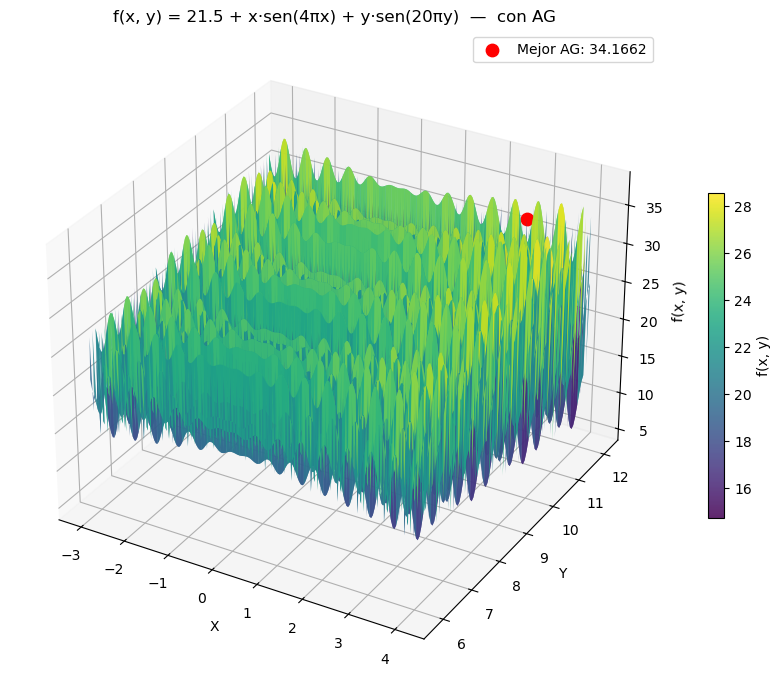

In [5]:
x_grid = np.linspace(RANGO[0, 0], RANGO[0, 1], 200)
y_grid = np.linspace(RANGO[1, 0], RANGO[1, 1], 200)
X, Y   = np.meshgrid(x_grid, y_grid)
 
feno_malla = np.column_stack([X.ravel(), Y.ravel()])
Z          = evaluar(feno_malla).reshape(X.shape)
 
fig = plt.figure(figsize=(10, 7))
ax  = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.85)
fig.colorbar(surf, ax=ax, shrink=0.5, label='f(x, y)')
 
ax.scatter(mejor_feno[0], mejor_feno[1], mejor_val,
           color='red', s=80, label=f'Mejor AG: {mejor_val:.4f}', zorder=5)
 
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('f(x, y)')
ax.set_title('f(x, y) = 21.5 + x·sen(4πx) + y·sen(20πy)  —  con AG')
ax.legend()
plt.tight_layout()
plt.show()

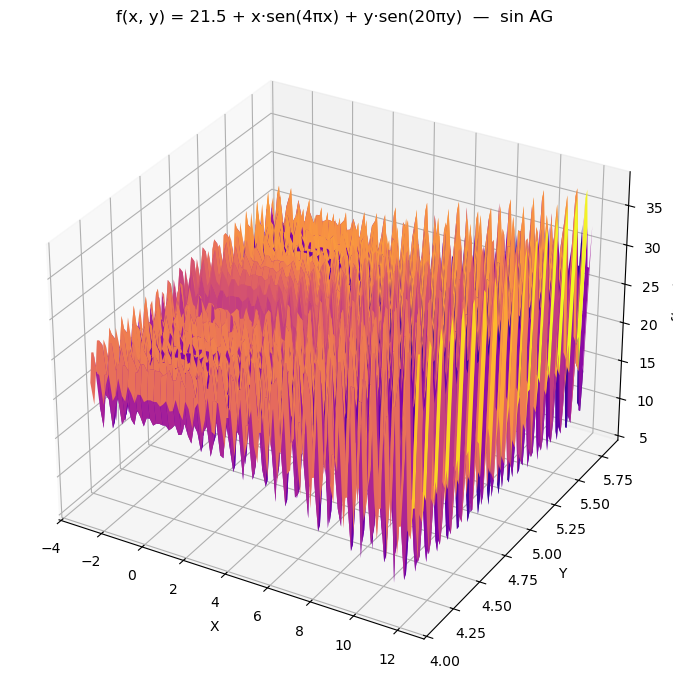

In [6]:
def f(x, y):
    return 21.5 + x * np.sin(4*np.pi*x) + y * np.sin(20*np.pi*y)
 
x2 = np.linspace(-3, 12.1, 100)
y2 = np.linspace(4.1, 5.8, 100)
X2, Y2 = np.meshgrid(x2, y2)
Z2 = f(X2, Y2)
 
fig2 = plt.figure(figsize=(10, 7))
ax2  = fig2.add_subplot(111, projection='3d')
ax2.plot_surface(X2, Y2, Z2, cmap='plasma')
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_zlabel('f(x, y)')
ax2.set_title('f(x, y) = 21.5 + x·sen(4πx) + y·sen(20πy)  —  sin AG')
plt.tight_layout()
plt.show()